In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score,
    recall_score, f1_score,
    confusion_matrix, classification_report
)

BASE_DIR = Path().resolve().parent
MODELS_DIR = BASE_DIR / 'models'
FIGURES_DIR = BASE_DIR / 'figures'

print(f"Projeto em: {BASE_DIR}")

/tmp/ipykernel_134264/1907743902.py:3: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


Projeto em: /home/edson-luiz/Projetos/TCC


In [2]:
def load(name):
    with open(MODELS_DIR / f'{name}.pkl', 'rb') as f:
        return pickle.load(f)

X_train = load('X_train_tfidf')
X_test  = load('X_test_tfidf')
y_train = load('y_train')
y_test  = load('y_test')

print(f"Treino : {X_train.shape}")
print(f"Teste  : {X_test.shape}")
print(f"\nDistribuição no teste:")
print(pd.Series(y_test).value_counts().rename({1: 'spam', 0: 'ham'}))

Treino : (26924, 10000)
Teste  : (6732, 10000)

Distribuição no teste:
label
spam    3435
ham     3297
Name: count, dtype: int64


In [5]:
models = {
    'Naive Bayes':        MultinomialNB(),
    'SVM':                LinearSVC(random_state=42, max_iter=2000, dual='auto'),
    'Random Forest':      RandomForestClassifier(
                              n_estimators=200,
                              random_state=42,
                              n_jobs=-1
                          ),
    'Regressão Logística': LogisticRegression(
                              max_iter=1000,
                              random_state=42,
                              n_jobs=-1
                          ),
}

In [6]:
results = []

for name, model in models.items():
    print(f"Treinando: {name}...")

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results.append({
        'Algoritmo':  name,
        'Acurácia':   accuracy_score(y_test, y_pred),
        'Precisão':   precision_score(y_test, y_pred, pos_label=1),
        'Recall':     recall_score(y_test, y_pred, pos_label=1),
        'F1-score':   f1_score(y_test, y_pred, pos_label=1),
    })

    # Salva o modelo treinado
    with open(MODELS_DIR / f'model_{name.lower().replace(" ", "_")}.pkl', 'wb') as f:
        pickle.dump(model, f)

print("\nConcluído.")

Treinando: Naive Bayes...
Treinando: SVM...
Treinando: Random Forest...
Treinando: Regressão Logística...

Concluído.


In [7]:
df_results = pd.DataFrame(results).set_index('Algoritmo')
df_results = df_results.sort_values('F1-score', ascending=False)

# Formata para exibição
df_display = df_results.applymap(lambda x: f'{x:.4f}')
print("=" * 60)
print("TABELA COMPARATIVA DE DESEMPENHO — RECORTE DE 150 PALAVRAS")
print("=" * 60)
print(df_display.to_string())
print("=" * 60)
print("Métrica principal: F1-score (spam como classe positiva)")

TABELA COMPARATIVA DE DESEMPENHO — RECORTE DE 150 PALAVRAS
                    Acurácia Precisão  Recall F1-score
Algoritmo                                             
Random Forest         0.9999   0.9997  1.0000   0.9999
SVM                   0.9996   0.9991  1.0000   0.9996
Regressão Logística   0.9993   0.9985  1.0000   0.9993
Naive Bayes           0.9848   0.9712  1.0000   0.9854
Métrica principal: F1-score (spam como classe positiva)


/tmp/ipykernel_134264/867725664.py:5: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_display = df_results.applymap(lambda x: f'{x:.4f}')


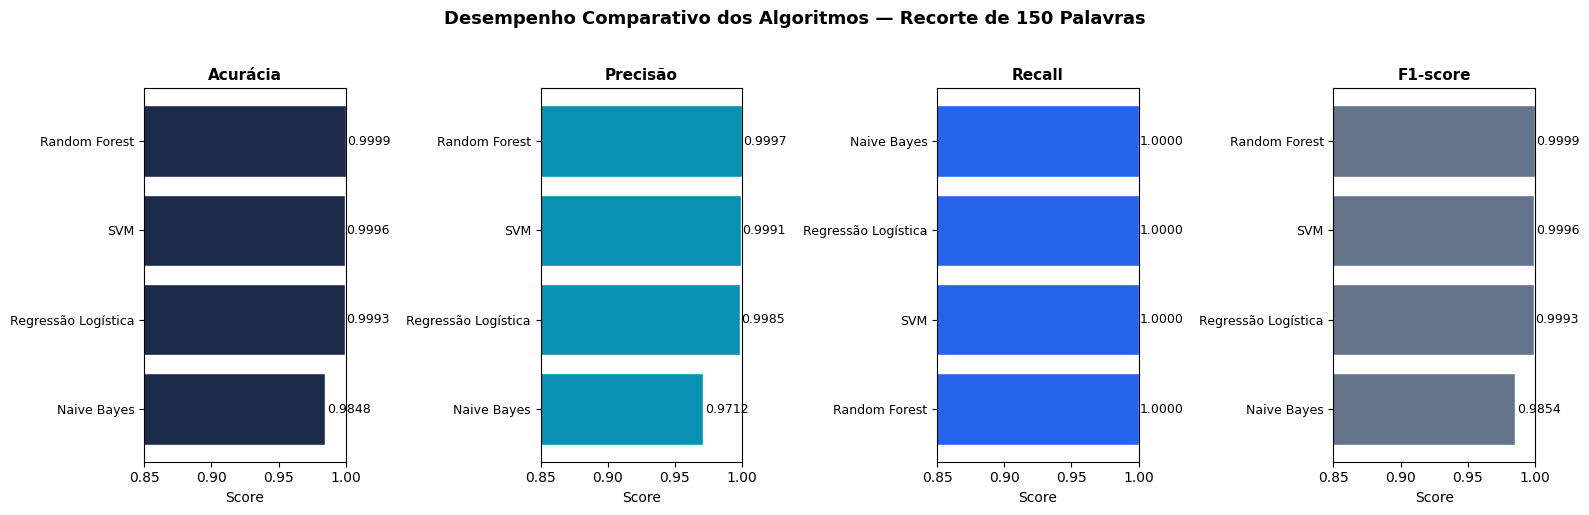

Figura salva: figures/comparative_metrics.png


In [8]:
metrics = ['Acurácia', 'Precisão', 'Recall', 'F1-score']
colors  = ['#1C2B4A', '#0891B2', '#2563EB', '#64748B']

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
fig.suptitle(
    'Desempenho Comparativo dos Algoritmos — Recorte de 150 Palavras',
    fontsize=13, fontweight='bold', y=1.02
)

for ax, metric, color in zip(axes, metrics, colors):
    valores = df_results[metric].sort_values(ascending=True)
    bars = ax.barh(valores.index, valores.values, color=color, edgecolor='white')
    ax.set_xlim(0.85, 1.0)
    ax.set_title(metric, fontweight='bold', fontsize=11)
    ax.set_xlabel('Score')
    ax.tick_params(axis='y', labelsize=9)
    for bar, val in zip(bars, valores.values):
        ax.text(val + 0.001, bar.get_y() + bar.get_height() / 2,
                f'{val:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'comparative_metrics.png', dpi=300, bbox_inches='tight')
plt.show()
print("Figura salva: figures/comparative_metrics.png")

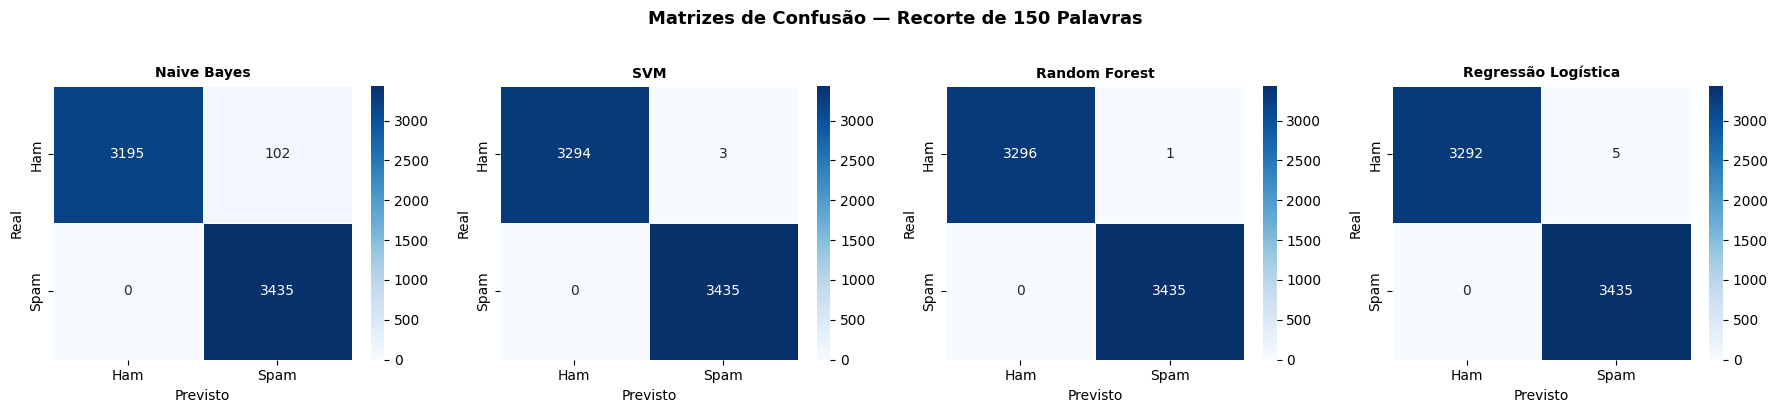

Figura salva: figures/confusion_matrices.png


In [9]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle(
    'Matrizes de Confusão — Recorte de 150 Palavras',
    fontsize=13, fontweight='bold', y=1.02
)

for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues', ax=ax,
        xticklabels=['Ham', 'Spam'],
        yticklabels=['Ham', 'Spam'],
        linewidths=0.5, linecolor='white'
    )
    ax.set_title(name, fontweight='bold', fontsize=10)
    ax.set_xlabel('Previsto')
    ax.set_ylabel('Real')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()
print("Figura salva: figures/confusion_matrices.png")

In [10]:
for name, model in models.items():
    y_pred = model.predict(X_test)
    print(f"\n{'=' * 50}")
    print(f"  {name}")
    print(f"{'=' * 50}")
    print(classification_report(
        y_test, y_pred,
        target_names=['Ham', 'Spam'],
        digits=4
    ))


  Naive Bayes
              precision    recall  f1-score   support

         Ham     1.0000    0.9691    0.9843      3297
        Spam     0.9712    1.0000    0.9854      3435

    accuracy                         0.9848      6732
   macro avg     0.9856    0.9845    0.9848      6732
weighted avg     0.9853    0.9848    0.9848      6732


  SVM
              precision    recall  f1-score   support

         Ham     1.0000    0.9991    0.9995      3297
        Spam     0.9991    1.0000    0.9996      3435

    accuracy                         0.9996      6732
   macro avg     0.9996    0.9995    0.9996      6732
weighted avg     0.9996    0.9996    0.9996      6732


  Random Forest
              precision    recall  f1-score   support

         Ham     1.0000    0.9997    0.9998      3297
        Spam     0.9997    1.0000    0.9999      3435

    accuracy                         0.9999      6732
   macro avg     0.9999    0.9998    0.9999      6732
weighted avg     0.9999    0.9999  

In [11]:
melhor = df_results['F1-score'].idxmax()
print(f"Melhor algoritmo por F1-score: {melhor}")
print(f"\nMétricas:")
print(df_results.loc[melhor].to_string())

# Análise de erros do melhor modelo
model_best  = models[melhor]
y_pred_best = model_best.predict(X_test)

fp = ((y_pred_best == 1) & (y_test == 0)).sum()   # falsos positivos
fn = ((y_pred_best == 0) & (y_test == 1)).sum()   # falsos negativos

print(f"\nAnálise de erros ({melhor}):")
print(f"  Falsos positivos (ham classificado como spam): {fp}")
print(f"  Falsos negativos (spam classificado como ham): {fn}")
print(f"\n  Em contexto de segurança, falsos negativos são")
print(f"  mais custosos — spam que passou pelo filtro.")

Melhor algoritmo por F1-score: Random Forest

Métricas:
Acurácia    0.999851
Precisão    0.999709
Recall      1.000000
F1-score    0.999854

Análise de erros (Random Forest):
  Falsos positivos (ham classificado como spam): 1
  Falsos negativos (spam classificado como ham): 0

  Em contexto de segurança, falsos negativos são
  mais custosos — spam que passou pelo filtro.


In [12]:
df_results.to_csv(MODELS_DIR / 'results.csv')
print("Resultados salvos em: models/results.csv")
print("\nResumo final:")
print(df_results.round(4).to_string())

Resultados salvos em: models/results.csv

Resumo final:
                     Acurácia  Precisão  Recall  F1-score
Algoritmo                                                
Random Forest          0.9999    0.9997     1.0    0.9999
SVM                    0.9996    0.9991     1.0    0.9996
Regressão Logística    0.9993    0.9985     1.0    0.9993
Naive Bayes            0.9848    0.9712     1.0    0.9854


In [14]:
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer

import pickle
with open(MODELS_DIR / 'y_train.pkl', 'rb') as f:
    y_train_cv = pickle.load(f)
with open(MODELS_DIR / 'X_train_tfidf.pkl', 'rb') as f:
    X_train_cv = pickle.load(f)

print("Validação cruzada (5-fold) — F1-score no treino:")
print("Confirma que os resultados não são artefato do split\n")

cv_models = {
    'Naive Bayes':         MultinomialNB(),
    'SVM':                 LinearSVC(random_state=42, max_iter=2000, dual='auto'),
    'Random Forest':       RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'Regressão Logística': LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1),
}

for name, model in cv_models.items():
    scores = cross_val_score(
        model, X_train_cv, y_train_cv,
        cv=5, scoring='f1', n_jobs=-1
    )
    print(f"{name:<25} média={scores.mean():.4f}  std={scores.std():.4f}")

Validação cruzada (5-fold) — F1-score no treino:
Confirma que os resultados não são artefato do split

Naive Bayes               média=0.9858  std=0.0012
SVM                       média=0.9996  std=0.0002
Random Forest             média=0.9996  std=0.0003
Regressão Logística       média=0.9995  std=0.0003
